In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Create a simulated non-linear dataset
np.random.seed(0)

# Independent variable (feature): X
X = np.sort(5 * np.random.rand(80, 1), axis=0)

# Dependent variable (target): y, with a non-linear relationship and noise
y = np.sin(X).ravel() + 2 * np.cos(X).ravel() + np.random.rand(80) * 0.5

print("Dataset created successfully. It shows a non-linear relationship.")
print("Sample data points (X, y):")
for i in range(5):
    print(f"X: {X[i][0]:.3f}, y: {y[i]:.3f}")

Dataset created successfully. It shows a non-linear relationship.
Sample data points (X, y):
X: 0.094, y: 2.244
X: 0.101, y: 2.298
X: 0.196, y: 2.188
X: 0.301, y: 2.553
X: 0.355, y: 2.506


In [3]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nData split: {len(X_train)} training samples, {len(X_test)} testing samples.")

# 3. Train the Random Forest Regressor model
forest_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
forest_model.fit(X_train, y_train)

print("Random Forest model training complete.")



Data split: 56 training samples, 24 testing samples.
Random Forest model training complete.


In [4]:
# 4. Make predictions on the testing data
y_pred = forest_model.predict(X_test)

print("Predictions made successfully.")
print("Sample predictions:")
for i in range(min(5, len(y_test))):
    print(f"  Actual: {y_test[i]:.2f}, Predicted: {y_pred[i]:.2f}")

# 5. Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Predictions made successfully.
Sample predictions:
  Actual: 0.49, Predicted: 0.79
  Actual: 2.24, Predicted: 2.30
  Actual: 1.92, Predicted: 1.80
  Actual: 0.34, Predicted: 0.12
  Actual: 2.36, Predicted: 2.02

Model Evaluation:
Mean Squared Error (MSE): 0.04
R-squared (R²): 0.99


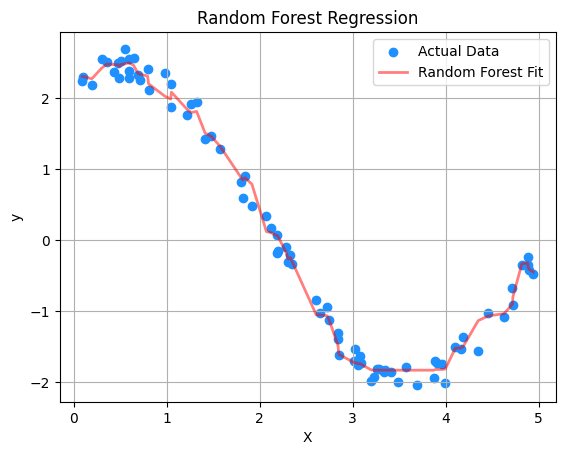

In [7]:
# 6. Visualize the Random Forest Regression
X_sorted = np.sort(X, axis=0)
y_pred_curve = forest_model.predict(X_sorted)

plt.scatter(X, y, color='dodgerblue', label='Actual Data')
plt.plot(X_sorted, y_pred_curve, color='red', linewidth=2, alpha = 0.5, label='Random Forest Fit')
plt.title('Random Forest Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()
